# Autonomous USV Path Planning: Exploring RRT and RRT*

Welcome to this training session on sampling-based path planning. In this assignment, you will explore how autonomous vehicles navigate through environments with obstacles.

We will focus on two foundational algorithms:
1. **Rapidly-exploring Random Tree (RRT):** A fast, heavily randomized algorithm that efficiently searches high-dimensional spaces but often yields jagged, suboptimal paths.
2. **RRT\* (Optimal RRT):** An extension of RRT that constantly "rewires" its tree to find shorter, more efficient paths, though at a higher computational cost.

---
## Part 1: The Algorithms (Pseudocode)

Before diving into the Python code, review the pseudocode below. Full paper is here: https://arxiv.org/pdf/1105.1186 (page 13-16)

### 1. Standard RRT Algorithm

The standard RRT builds a tree from the start node by randomly sampling points in the space and extending the tree toward those points.

![](https://drive.google.com/uc?export=view&id=1SFcWGdn_QdXeEBInalNFWgZIbLLHl9pj)


### 2. RRT* Algorithm

RRT* improves upon RRT by keeping track of the "cost" (distance traveled from the start) and rewiring the tree to ensure nodes are connected via the shortest possible path.

![](https://drive.google.com/uc?export=view&id=1Pyo5XqWRWfpMVepHL_oj23eQXqek68Eq)


In [ ]:
!git clone https://github.com/cybergalactic/PythonVehicleSimulator.git
!cd /content/PythonVehicleSimulator && /usr/bin/python3 -m pip install -e .
# reinitializing python configuration after installing the package
import site
site.main()

fatal: destination path 'PythonVehicleSimulator' already exists and is not an empty directory.
Obtaining file:///content/PythonVehicleSimulator
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for python_vehicle_simulator (pyproject.toml) ... done
  Created wheel for python_vehicle_simulator: filename=python_vehicle_simulator-1.0.1-0.editable-py3-none-any.whl size=2566 sha256=b19af2ca2ea75d30ec46b7b41afa11ff7ddacd9b4066f7e5bc8733f383b3bde3
  Stored in directory: /tmp/pip-ephem-wheel-cache-38amz376/wheels/65/43/c7/aafc065f1742b4740af693ec5b7d2d47ff8dcbbe75c6a2ef5f
Successfully built python_vehicle_simulator
  Attempting uninstall: python_vehicle_simulator
    Found existing installation: python_vehicle_simulator 1.0.1
    Uninstalling python_vehicle_simulator-1.0.1:
      Successfully uninstalled python_vehicle

# Implement the missing code

Notice that several critical steps are missing (`[TODO]`). You will need to apply your understanding of RRT and RRT* to complete the actual Python implementation in the code cells below.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np

class Node:
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.parent = None

def get_distance(n1: Node, n2: Node) -> float:
    return np.sqrt((n1.x - n2.x)**2 + (n1.y - n2.y)**2)

def is_segment_collision_free(p1, p2, obstacles):
    """
    Checks if the line segment between p1 and p2 intersects any circular obstacle.
    """
    p1, p2 = (p1.x, p1.y), (p2.x, p2.y)
    for (ox, oy, r) in obstacles:
        center = np.array([ox, oy])
        a = np.array(p1)
        b = np.array(p2)

        # Vector from A to B and A to Center
        ab = b - a
        ac = center - a

        # Project ac onto ab to find the closest point on the line
        # clamp t to [0, 1] to stay on the segment
        t = np.dot(ac, ab) / np.dot(ab, ab)
        t = max(0, min(1, t))

        closest_point = a + t * ab
        dist_to_circle = np.linalg.norm(closest_point - center)

        if dist_to_circle < r:
            return False # Collision detected
    return True

def random_sampling_node(bounds: tuple) -> Node:
    # TODO
    return raise NotImplementedError("Implement the random sampling node!")

def get_nearest_node(tree: list[Node], node: Node) -> Node:
    # TODO
    return raise NotImplementedError("Implement to get nearest node!")

def construct_path(node: Node) -> list[Node]:
    # TODO
    return raise NotImplementedError("Implement to cosntruct the path!")

def rrt(start: tuple, goal: tuple, obstacles: list[tuple], bounds: tuple, step_size: float=0.5, max_iter: int=3000) -> list[Node]:
    """
    start: (x, y)
    goal: (x, y, radius)
    bounds: (min_x, max_x, min_y, max_y)
    """
    tree = [Node(start[0], start[1])]
    goal_node = Node(goal[0], goal[1])
    goal_radius = goal[2]

    for i in range(max_iter):
        # 1. Sample
        random_node = random_sampling_node(bounds)

        # 2. Nearest Node
        nearest_node = get_nearest_node(tree, random_node)

        # 3. Extend Towards
        theta = np.arctan2(random_node.y - nearest_node.y, random_node.x - nearest_node.x)
        new_x = nearest_node.x + step_size * np.cos(theta)
        new_y = nearest_node.y + step_size * np.sin(theta)
        new_node = Node(new_x, new_y)

        # 4. Segment Collision Check
        if is_segment_collision_free(nearest_node, new_node, obstacles):
            new_node.parent = nearest_node
            tree.append(new_node)

            # 5. Goal check
            if get_distance(new_node, goal_node) <= goal_radius:
                return construct_path(new_node)

    return None

def get_nearby_nodes(tree: list[Node], node: Node, search_radius: float) -> list[Node]:
    # TODO
    return raise NotImplementedError("Implement to get nearby nodes!")

def get_best_parent(nearby_nodes: list[Node], nearest_node: Node, new_node: Node, obstacles: tuple) -> tuple[Node, float]:
    # TODO
    return raise NotImplementedError("Implement to get the best parent and the minimum cost!")
    return best_parent, min_cost

def rrt_star(start: tuple, goal: tuple, obstacles: list[tuple], bounds: tuple, step_size: float=0.5, max_iter: int=3000, search_radius: float=1.5) -> list[Node]:
    """
    start: (x, y)
    goal: (x, y, radius)
    bounds: (min_x, max_x, min_y, max_y)
    search_radius: radius to look for neighboring nodes for rewiring
    """
    start_node = Node(start[0], start[1])
    start_node.cost = 0.0 # Ensure your Node class supports cost tracking
    tree = [start_node]
    goal_node = Node(goal[0], goal[1])
    goal_radius = goal[2]

    best_goal_node = None

    for i in range(max_iter):
        # 1. Sample
        random_node = random_sampling_node(bounds)

        # 2. Nearest Node
        nearest_node = get_nearest_node(tree, random_node)

        # 3. Extend Towards
        theta = np.arctan2(random_node.y - nearest_node.y, random_node.x - nearest_node.x)
        new_x = nearest_node.x + step_size * np.cos(theta)
        new_y = nearest_node.y + step_size * np.sin(theta)
        new_node = Node(new_x, new_y)

        # 4. Check if the initial step is collision-free
        if is_segment_collision_free(nearest_node, new_node, obstacles):
            # Find all nearby nodes within the search radius
            nearby_nodes = get_nearby_nodes(tree, new_node, search_radius)

            # --- RRT* STEP A: Choose Best Parent ---
            best_parent, min_cost = get_best_parent(nearby_nodes, nearest_node, new_node, obstacles)
            new_node.parent = best_parent
            new_node.cost = min_cost
            tree.append(new_node)

            # --- RRT* STEP B: Rewire the Tree ---
            for near_node in nearby_nodes:
                # TODO
                raise NotImplementedError("Implement to rewire the tree!")

            # 5. Goal check (Track the best path instead of returning immediately)
            if get_distance(new_node, goal_node) <= goal_radius:
                if best_goal_node is None or new_node.cost < best_goal_node.cost:
                    best_goal_node = new_node

    # 6. Extract the best path found after all iterations
    if best_goal_node:
        return construct_path(best_goal_node)

    return None

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
import time
from python_vehicle_simulator.vehicles import otter
from python_vehicle_simulator.lib import attitudeEuler

def run_path_planning(path_planning_method = "RRT", # RRT or RRT*
                      guidance_strategy = "CB", # CB, PP, or LOS
                      start_point = (0.0,-20.0), # (x, y)
                      goal_region = (200, 200, 10.0), # (x, y, radius)
                      bounds = (-25, 225, -25, 225), # (min_x, max_x, min_y, max_y)
                      obstacles = [(80, 80, 30), (50, 120, 30), (150, 100, 28)], # list of circle (x_center,y_center,radius)
                      step_size = 20.0, # Parameter for RRT and RRT*
                      search_radius = 50.0, # Parameter for RRT*
                      radius_acceptance = 15.0,
                      lookahead_distance = 20.0, # Parameter for guidance
                      kappa = 2.5, # Parameter for CB
                      sim_time = 1200.0, # Increase simulation time to complete the path following
                      sampleTime = 0.05,
                      ):
    def sawtooth(x):
        return 2 * np.arctan(np.tan(x / 2))

    # --- 1. OTTER USV CONTROLLER ---
    class myOtter(otter):
        def __init__(self, controlSystem, u_d, V_current, beta_current):
            mycontrolSystem = str(controlSystem)
            super().__init__(controlSystem, 0, V_current, beta_current, 0)
            self.D2R = np.pi / 180
            if mycontrolSystem == "my_controller":
                self.u_d = u_d
                self.a_d = 0
                self.r_d = 0
                self.e_u_int = 0
                self.e_psi_int = 0
                self.controlMode = mycontrolSystem

        def my_controller(self, eta, nu, ref, sampleTime):
            psi, r, u = eta[5], nu[5], nu[0]
            u_d, psi_d, r_d = ref[0], ref[1], ref[2]

            e_psi = sawtooth(psi - psi_d)
            e_r = r - r_d
            e_u = u - u_d

            self.e_u_int += e_u * sampleTime
            self.e_psi_int += e_psi * sampleTime

            # Tuned Gains
            Kpu, Kiu = 150., 10.
            Kpy, Kiy, Kdy = 50.0, 0.1, 20.0

            tau_X = -Kpu * e_u - Kiu * self.e_u_int
            tau_N = -Kpy * e_psi - Kiy * self.e_psi_int - Kdy * e_r

            tau = np.array([tau_X, tau_N])
            u_alloc = np.matmul(self.Binv, tau)

            n_left = np.sign(u_alloc[0]) * math.sqrt(abs(u_alloc[0]))
            n_right = np.sign(u_alloc[1]) * math.sqrt(abs(u_alloc[1]))

            return np.array([n_left, n_right], float), e_u, e_psi, 0

    # --- 2. SIMULATION FUNCTION ---
    def simulate_path_planning(N, sampleTime, vehicle, strategy="CB"):
        DOF = 6
        eta = np.array([start_point[0], start_point[1], 0, 0, 0, 0], float) # Start slightly off-path
        nu = vehicle.nu
        u_actual = vehicle.u_actual
        simData = np.empty([0, 2 * DOF + 2 * vehicle.dimU], float)

        print(f"Path planning starts...")
        path_planning_start_time = time.perf_counter()

        if path_planning_method == "RRT*":
            path = np.array(rrt_star(start_point, goal_region, obstacles, bounds, step_size = step_size, search_radius = search_radius))
        else: # RRT
            path = np.array(rrt(start_point, goal_region, obstacles, bounds, step_size = step_size))

        path_planning_end_time = time.perf_counter()
        path_planning_duration = path_planning_end_time - path_planning_start_time
        print(f"Path planning execution time: {path_planning_duration:.6f} seconds")

        waypoints = []
        for i in range(len(path)):
            waypoints.append([path[i].x, path[i].y])
        waypoints = np.array(waypoints)

        wp_idx = 0
        R_accept = radius_acceptance # Circle of acceptance to switch to next waypoint
        Delta = lookahead_distance # Lookahead distance

        for i in range(0, N + 1):
            t = i * sampleTime
            pr = np.array([eta[0], eta[1]], float)

            # Waypoint Switching Logic
            if wp_idx < len(waypoints) - 1:
                p_k = waypoints[wp_idx]
                p_k_next = waypoints[wp_idx + 1]

                # Distance to the NEXT waypoint
                dist_to_next = np.linalg.norm(pr - p_k_next)
                if dist_to_next < R_accept:
                    wp_idx += 1
                    if wp_idx >= len(waypoints) - 1:
                        # End of path reached
                        u_d = 0.0
                        psi_d = eta[5]
                        continue
            else:
                p_k = waypoints[-2]
                p_k_next = waypoints[-1]

            # Path Geometry
            alpha = np.arctan2(p_k_next[1] - p_k[1], p_k_next[0] - p_k[0])

            # Cross-track error (e_y) and along-track distance (s)
            e_y = -(pr[0] - p_k[0]) * np.sin(alpha) + (pr[1] - p_k[1]) * np.cos(alpha)
            s = (pr[0] - p_k[0]) * np.cos(alpha) + (pr[1] - p_k[1]) * np.sin(alpha)

            # Base desired speed
            u_d = vehicle.u_d if wp_idx < len(waypoints) - 1 else 0.0

            # --- GUIDANCE STRATEGIES ---
            if strategy == "LOS":
                # Line-of-Sight Path Following
                psi_d = alpha + np.arctan(-e_y / Delta)

            elif strategy == "PP":
                # Pure Pursuit (Aiming at a virtual point Delta meters ahead on path)
                p_target = p_k + (s + Delta) * np.array([np.cos(alpha), np.sin(alpha)])
                psi_d = np.arctan2(p_target[1] - pr[1], p_target[0] - pr[0])

            elif strategy == "CB":
                # Constant Bearing (Chasing a virtual target moving along the path)
                p_target = p_k + (s + Delta) * np.array([np.cos(alpha), np.sin(alpha)])
                v_target = u_d * np.array([np.cos(alpha), np.sin(alpha)]) # Target velocity vector

                p_tilde = pr - p_target
                dist_t = np.linalg.norm(p_tilde)

                if dist_t > 0.1:
                    v_a = -kappa * (p_tilde / dist_t)
                    v_d = v_target + v_a
                    psi_d = np.arctan2(v_d[1], v_d[0])
                else:
                    psi_d = alpha

            r_d = 0.0
            z_d = vehicle.z_d if hasattr(vehicle, 'z_d') else 0

            # Apply to Controller
            ref = np.array([u_d, psi_d, r_d, z_d], float)
            u_control, e_u, e_yaw, e_z = vehicle.my_controller(eta, nu, ref, sampleTime)

            # Store data & Propagate dynamics
            signals = np.append(np.append(np.append(eta, nu), u_control), u_actual)
            simData = np.vstack([simData, signals])

            nu, u_actual = vehicle.dynamics(eta, nu, u_actual, u_control, sampleTime)
            eta = attitudeEuler(eta, nu, sampleTime)

        simTime = np.arange(start=0, stop=t + sampleTime, step=sampleTime)[:, None]
        return simTime, simData, waypoints, obstacles, path_planning_duration

    # --- 3. RUN AND PLOT ---
    N = int(sim_time / sampleTime)

    otter_usv = myOtter("my_controller", u_d=1.0, V_current=0., beta_current=0.)

    plt.figure(figsize=(10, 8))

    simTime, simData, WPs, obstacles, path_planning_duration = simulate_path_planning(N, sampleTime, otter_usv, strategy=guidance_strategy)
    plt.plot(simData[:, 0], simData[:, 1], linewidth=2, label=f'Guidance: {guidance_strategy}')

    # Plot the geometric path
    wp_x = WPs[:, 0]
    wp_y = WPs[:, 1]
    plt.plot(wp_x, wp_y, 'k--', linewidth=2, label='Desired Path')

    # Plot waypoints
    plt.scatter(wp_x, wp_y, c='k', marker='o', s=80, zorder=5, label='Waypoints')
    plt.scatter(start_point[0], start_point[1], c='magenta', marker='s', s=100, zorder=5, label='USV Start')

    # Draw Circles of Acceptance around waypoints
    ax = plt.gca()
    for i in range(1, len(WPs)-1):
        circle = plt.Circle((WPs[i, 0], WPs[i, 1]), radius_acceptance, color='gray', fill=False, linestyle=':')
        ax.add_patch(circle)

    # Draw obstacles
    for obstacle in obstacles:
        x_c, y_c, r = obstacle
        circle = plt.Circle((x_c, y_c), r, color='black', fill=True, linewidth=2)
        ax.add_patch(circle)

    plt.title("Path planning with "+path_planning_method+" with "+guidance_strategy+" guidance")
    plt.xlabel("X (North) [m]")
    plt.ylabel("Y (East) [m]")
    plt.grid(True)
    plt.axis('equal')
    plt.legend()
    plt.show()

    return simTime, simData, WPs, obstacles, path_planning_duration

Path planning starts...
Path planning execution time: 0.240506 seconds


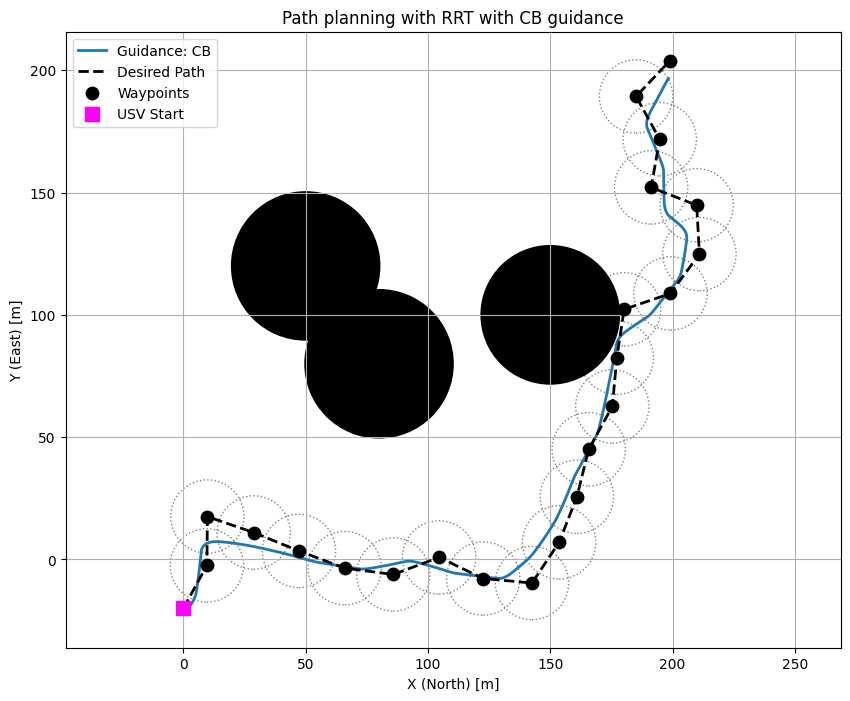

In [ ]:
simTime, simData, WPs, obstacles, path_planning_duration = \
  run_path_planning(path_planning_method = "RRT", # RRT or RRT*
                      guidance_strategy = "CB", # CB, PP, or LOS
                      start_point = (0.0,-20.0), # (x, y)
                      goal_region = (200, 200, 10.0), # (x, y, radius)
                      bounds = (-25, 225, -25, 225), # (min_x, max_x, min_y, max_y)
                      obstacles = [(80, 80, 30), (50, 120, 30), (150, 100, 28)], # list of circle (x_center,y_center,radius)
                      step_size = 20.0, # Parameter for RRT and RRT*
                      search_radius = 50.0, # Parameter for RRT*
                      radius_acceptance = 15.0,
                      lookahead_distance = 20.0, # Parameter for guidance
                      kappa = 2.5, # Parameter for CB
                      sim_time = 1200.0, # Increase simulation time to complete the path following
                      sampleTime = 0.05,
                      )

Path planning starts...
Path planning execution time: 19.830934 seconds


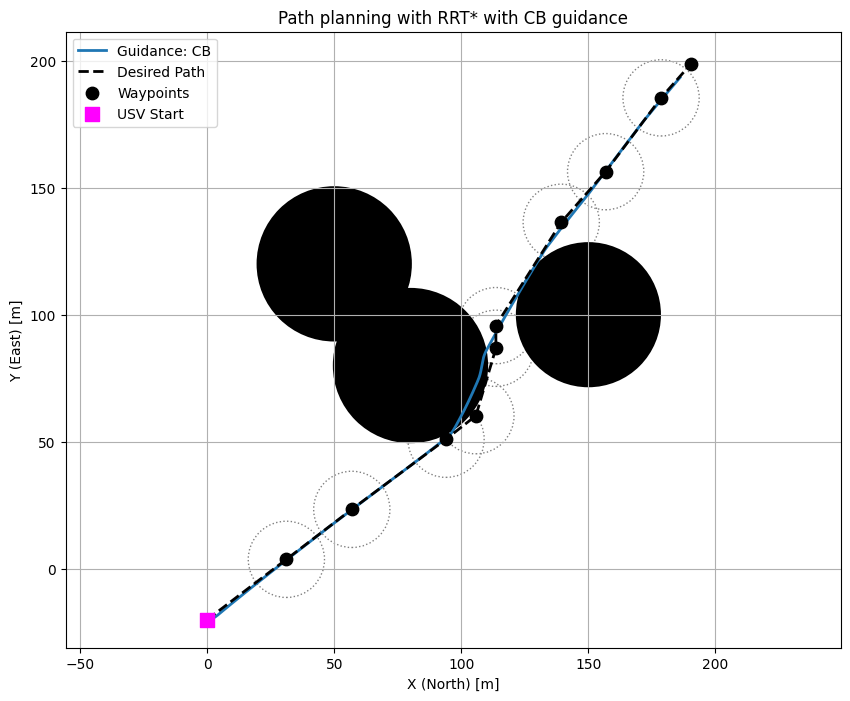

In [ ]:
simTime, simData, WPs, obstacles, path_planning_duration = \
  run_path_planning(path_planning_method = "RRT*", # RRT or RRT*
                      guidance_strategy = "CB", # CB, PP, or LOS
                      start_point = (0.0,-20.0), # (x, y)
                      goal_region = (200, 200, 10.0), # (x, y, radius)
                      bounds = (-25, 225, -25, 225), # (min_x, max_x, min_y, max_y)
                      obstacles = [(80, 80, 30), (50, 120, 30), (150, 100, 28)], # list of circle (x_center,y_center,radius)
                      step_size = 20.0, # Parameter for RRT and RRT*
                      search_radius = 50.0, # Parameter for RRT*
                      radius_acceptance = 15.0,
                      lookahead_distance = 20.0, # Parameter for guidance
                      kappa = 2.5, # Parameter for CB
                      sim_time = 1200.0, # Increase simulation time to complete the path following
                      sampleTime = 0.05,
                      )

# Analysis

### 1. The price of optimality

Run both the standard RRT and RRT* algorithms using the default parameters provided in the script. You will notice a difference in both the execution time and the geometric shape of the path. Why RRT* takes longer to compute?

### 2. Algorithmic Consistency and Randomness

Because both algorithms rely on random sampling, running the same code five times will yield five different paths. Run the standard RRT algorithm 5 separate times and plot/save the results. How drastically does the path change between runs? Does the execution time fluctuate?

### 3. Implementing Goal Bias

Look closely at the `random_sampling_node` function. Currently, it samples points uniformly across the entire simulation boundary. This means the algorithm searches completely blindly.

Rewrite the `random_sampling_node` function to accept two new parameters: `goal_node` and `goal_bias_prob`. Modify the logic so that with a probability of `goal_bias_prob` (e.g., 10%), the function returns the exact coordinates of the goal instead of a random point.
Run standard RRT with a goal bias of 0% (default), 5%, 20%, and 80%.

How does increasing the goal bias affect the execution time? What happens to the success rate and path shape when the goal bias is set too high (like 80%) in an environment with complex obstacles?

### 4. The Kinematic vs Dynamic Gap

The RRT and RRT* planners in this code are kinematic—they assume the vehicle is a point mass that can move in any direction instantly. However, the simulation uses a dynamic controller that obeys the laws of physics.

How does this discrepancy affect the vehicle's ability to stay inside the radius_acceptance at each waypoint?

If you were tasked with modifying the path planning phase (RRT/RRT*) so that it generates paths the Otter USV can follow more easily, what constraints would you add to the `is_segment_collision_free` or `Extend Towards` steps?

In [ ]:
# TODO: Write your code here for analysis